In [1]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 26.0 MB/s eta 0:00:00


In [2]:
!apt-get update -qq
!apt-get install fonts-nanum -qq

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [3]:
!pip install folium mapclassify

In [32]:
import pandas as pd
import numpy as np

# 1. 데이터 로드 (인코딩 주의)
df = pd.read_csv('/content/drive/MyDrive/비타민/서울시 공모전/seoul_crime.csv', encoding='cp949')
df.head()

,BASE_DATE,ADM_CD,ADM_NM,살인_majority,강도_majority,방화_majority,성폭력_majority,폭력_majority,절도_majority,마약_majority,도박_majority
0,20250630,11010530,사직동,2,2,2,3,3,3,2,3
1,20250630,11010540,삼청동,1,1,3,2,5,5,2,1
2,20250630,11010550,부암동,1,1,2,2,4,4,2,3
3,20250630,11010560,평창동,3,2,2,2,5,3,2,2
4,20250630,11010570,무악동,3,1,2,3,4,4,3,3


In [33]:
district_mapping = df[['ADM_CD', 'ADM_NM']].drop_duplicates()
print(district_mapping[district_mapping['ADM_NM'] == '신사동'])

       ADM_CD ADM_NM
329  11210680    신사동
358  11230510    신사동


In [34]:
df.iloc[329]

,329
BASE_DATE,20250630
ADM_CD,11210680
ADM_NM,신사동
살인_majority,2
강도_majority,3
방화_majority,1
성폭력_majority,2
폭력_majority,2
절도_majority,3
마약_majority,3


In [35]:
df = df.rename(columns={
    'ADM_NM': '행정동'
})

df_selected = df[['행정동', '살인_majority', '강도_majority', '방화_majority', '성폭력_majority', '폭력_majority', '절도_majority', '마약_majority', '도박_majority']].copy()

df_selected.head()

,행정동,살인_majority,강도_majority,방화_majority,성폭력_majority,폭력_majority,절도_majority,마약_majority,도박_majority
0,사직동,2,2,2,3,3,3,2,3
1,삼청동,1,1,3,2,5,5,2,1
2,부암동,1,1,2,2,4,4,2,3
3,평창동,3,2,2,2,5,3,2,2
4,무악동,3,1,2,3,4,4,3,3


In [36]:
df_check = df_selected[df_selected['행정동'].isin(['상일동','상일1동', '상일2동', '강일동','개포3동','일원2동'])]
df_check

,행정동,살인_majority,강도_majority,방화_majority,성폭력_majority,폭력_majority,절도_majority,마약_majority,도박_majority
359,개포3동,1,1,1,4,1,2,1,2
423,강일동,1,2,3,3,1,2,2,2
424,상일1동,1,2,3,3,1,2,2,2
425,상일2동,1,2,3,3,1,2,2,2


In [37]:
import pandas as pd

# 1. 상일1동을 상일동으로 수정
df_selected['행정동'] = df_selected['행정동'].replace('상일1동', '상일동')

# 2. 상일2동 데이터 삭제
# 상일2동이 아닌 행들만 남기는 방식(Filtering)을 사용합니다.
df_selected = df_selected[df_selected['행정동'] != '상일2동'].reset_index(drop=True)

# 3. 결과 확인
print("--- 행정동 정제 완료 ---")
check_sangil = df_selected[df_selected['행정동'].str.contains('상일')]
display(check_sangil)

--- 행정동 정제 완료 ---


,행정동,살인_majority,강도_majority,방화_majority,성폭력_majority,폭력_majority,절도_majority,마약_majority,도박_majority
424,상일동,1,2,3,3,1,2,2,2


In [39]:
admin_dong_map = pd.read_csv("/content/drive/MyDrive/비타민/서울시 공모전/자치구_행정동.csv")

In [40]:
admin_dong_map.head()

,행정동코드,행정동,area_km2,자치구,Unnamed: 4
0,11010530,사직동,1.157671,종로구,NaN
1,11010540,삼청동,1.477188,종로구,NaN
2,11010550,부암동,2.273287,종로구,NaN
3,11010560,평창동,8.940413,종로구,NaN
4,11010570,무악동,0.369245,종로구,NaN


In [41]:
# 1. 각 데이터셋의 동 이름 추출 (공백 제거 후 고유값만)
df_dongs = set(df_selected['행정동'].str.strip().unique())
map_dongs = set(admin_dong_map['행정동'].str.strip().unique())

# 2. 통계 산출
common_dongs = df_dongs.intersection(map_dongs)       # 교집합 (겹치는 동)
only_df = df_dongs - map_dongs                      # df에만 있는 동
only_map = map_dongs - df_dongs                       # admin_dong_map에만 있는 동

# 3. 결과 출력
print(f"--- [데이터 대조 결과 보고서] ---")
print(f"1. df (독거노인) 동 개수: {len(df_dongs)}개")
print(f"2. admin_dong_map (지도) 동 개수: {len(map_dongs)}개")
print(f"3. 완벽히 일치하는 동 개수: {len(common_dongs)}개")
print(f"4. 이름이 달라 매칭 실패한 동 개수: {len(only_df) + len(only_map)}개")

print("\n--- [체크 필요: df에만 있는 동 (일부)] ---")
print(sorted(list(only_df))[:20])  # 상위 20개만 출력

print("\n--- [체크 필요: admin_dong_map에만 있는 동 (일부)] ---")
print(sorted(list(only_map))[:20])   # 상위 20개만 출력

--- [데이터 대조 결과 보고서] ---
1. df (독거노인) 동 개수: 424개
2. admin_dong_map (지도) 동 개수: 424개
3. 완벽히 일치하는 동 개수: 424개
4. 이름이 달라 매칭 실패한 동 개수: 0개

--- [체크 필요: df에만 있는 동 (일부)] ---
[]

--- [체크 필요: admin_dong_map에만 있는 동 (일부)] ---
[]


In [42]:
merged_df = df_selected.merge(
    admin_dong_map[['행정동코드', '행정동', '자치구']],
    on='행정동',
    how='left'
)

In [43]:
sinsa_check = merged_df[merged_df['행정동'] == '신사동']
print(sinsa_check)

     행정동  살인_majority  강도_majority  방화_majority  성폭력_majority  폭력_majority  \
329  신사동            2            3            1             2            2   
330  신사동            2            3            1             2            2   
359  신사동            4            5            5             5            4   
360  신사동            4            5            5             5            4   

     절도_majority  마약_majority  도박_majority     행정동코드  자치구  
329            3            3            4  11210680  관악구  
330            3            3            4  11230510  강남구  
359            5            5            5  11210680  관악구  
360            5            5            5  11230510  강남구  


In [44]:
# 1. 문제가 되는 인덱스 제거
merged_df_final = merged_df.drop([330, 359])

# 2. 인덱스 초기화 (기존 인덱스는 삭제)
merged_df_final = merged_df_final.reset_index(drop=True)

# 확인
print(merged_df_final[merged_df_final['행정동'] == '신사동'])

     행정동  살인_majority  강도_majority  방화_majority  성폭력_majority  폭력_majority  \
329  신사동            2            3            1             2            2   
358  신사동            4            5            5             5            4   

     절도_majority  마약_majority  도박_majority     행정동코드  자치구  
329            3            3            4  11210680  관악구  
358            5            5            5  11230510  강남구  


# 가중치 설정

*   살인, 성폭력, 방화: 매우 중요 -> 모아센터와 연관성
*   도박 제거: 적고, 치안에 유의미한 영향 없다고 판단
*   절도, 폭력: 도심 집중 경향 -> 주택가의 치안과는 연관성 상대적 낮음
*   마약: 치안과 영향 상대적 낮음
*   강도: 강력 범죄이므로 절도보다 높은 가중치





In [45]:
weights = {
    '살인_majority': 2.0, '성폭력_majority': 2.0, '강도_majority': 1.5,
    '폭력_majority': 1.0, '절도_majority': 1.0, '방화_majority': 2.0,
    '마약_majority': 0.5
}

# 종합 점수 계산
merged_df_final['CRIME_SCORE_raw'] = sum(merged_df_final[col] * weight for col, weight in weights.items()) / sum(weights.values())
f_min = merged_df_final['CRIME_SCORE_raw'].min()
f_max = merged_df_final['CRIME_SCORE_raw'].max()

merged_df_final['CRIME_SCORE'] = ((merged_df_final['CRIME_SCORE_raw'] - f_min) / (f_max - f_min))*100
merged_df_final['CRIME_SCORE'] = merged_df_final['CRIME_SCORE'].round(0).astype(int)

merged_df_final.head()

,행정동,살인_majority,강도_majority,방화_majority,성폭력_majority,폭력_majority,절도_majority,마약_majority,도박_majority,행정동코드,자치구,CRIME_SCORE_raw,CRIME_SCORE
0,사직동,2,2,2,3,3,3,2,3,11010530,종로구,2.40,38
1,삼청동,1,1,3,2,5,5,2,1,11010540,종로구,2.45,39
2,부암동,1,1,2,2,4,4,2,3,11010550,종로구,2.05,28
3,평창동,3,2,2,2,5,3,2,2,11010560,종로구,2.60,43
4,무악동,3,1,2,3,4,4,3,3,11010570,종로구,2.70,46


In [46]:
# 점수 기준 내림차순 정렬 (상위 20개 행정동 추출)
# 'ADM_NM'은 행정동 명칭, 'GU_NAME'은 구 명칭 컬럼이라고 가정합니다.
top_danger_areas = merged_df_final.sort_values(by='CRIME_SCORE', ascending=False)


print("--- 모아센터 설치 시급 지역 (치안 위험도 상위) ---")
top_danger_areas[['행정동', 'CRIME_SCORE']].head(20)

--- 모아센터 설치 시급 지역 (치안 위험도 상위) ---


,행정동,CRIME_SCORE
358,신사동,100
366,역삼1동,100
301,영등포동,99
211,합정동,97
210,서교동,97
386,방이1동,93
312,사당5동,93
311,사당4동,93
309,사당1동,93
390,송파1동,93


In [48]:
# 점수 기준 내림차순 정렬 (상위 20개 행정동 추출)
# 'ADM_NM'은 행정동 명칭, 'GU_NAME'은 구 명칭 컬럼이라고 가정합니다.
low_danger_areas = merged_df_final.sort_values(by='CRIME_SCORE', ascending=True)


print("--- 모아센터 설치 시급 지역 (치안 위험도 상위) ---")
low_danger_areas[['행정동', 'CRIME_SCORE']].head(20)

--- 모아센터 설치 시급 지역 (치안 위험도 상위) ---


,행정동,CRIME_SCORE
38,이촌1동,0
409,고덕1동,0
410,고덕2동,0
132,번3동,5
197,홍은2동,5
188,진관동,5
80,회기동,7
357,내곡동,7
129,석관동,9
108,면목3·8동,9


In [49]:
merged_df_final = merged_df_final[['행정동코드', '자치구', '행정동', 'CRIME_SCORE']]

In [50]:
merged_df_final.head(10)

,행정동코드,자치구,행정동,CRIME_SCORE
0,11010530,종로구,사직동,38
1,11010540,종로구,삼청동,39
2,11010550,종로구,부암동,28
3,11010560,종로구,평창동,43
4,11010570,종로구,무악동,46
5,11010580,종로구,교남동,46
6,11010600,종로구,가회동,39
7,11010610,종로구,종로1·2·3·4가동,66
8,11010630,종로구,종로5·6가동,69
9,11010640,종로구,이화동,50


In [51]:
merged_df_final[['행정동코드', '자치구', '행정동', 'CRIME_SCORE']].to_csv(
    'crime_score.csv',
    index=False,
    encoding='utf-8-sig'
)

In [52]:
import geopandas as gpd
admin_gdf = gpd.read_file('/content/drive/MyDrive/비타민/서울시 공모전/bnd_dong_11_2025_2Q.shp', encoding='utf-8')

In [53]:
admin_gdf.head()

,BASE_DATE,ADM_CD,ADM_NM,geometry
0,20250630,11010530,사직동,"POLYGON ((953553.932 1953335.741, 953555.211 1..."
1,20250630,11010540,삼청동,"POLYGON ((953844.082 1955492.177, 953858.644 1..."
2,20250630,11010550,부암동,"POLYGON ((952490.38 1956548.821, 952497.594 19..."
3,20250630,11010560,평창동,"POLYGON ((953683.828 1959209.871, 953665.283 1..."
4,20250630,11010570,무악동,"POLYGON ((952298.144 1953539.606, 952324.838 1..."


In [54]:
import pandas as pd
import geopandas as gpd
from shapely.ops import unary_union

# 1. 상일1동 -> 상일동 명칭 수정
admin_gdf.loc[admin_gdf['ADM_NM'] == '상일1동', 'ADM_NM'] = '상일동'

# 2. 강일동과 상일2동 geometry 통합
# 강일동과 상일2동의 geometry만 추출
gangil_geom = admin_gdf[admin_gdf['ADM_NM'] == '강일동'].geometry.values[0]
sangil2_geom = admin_gdf[admin_gdf['ADM_NM'] == '상일2동'].geometry.values[0]

# 두 geometry를 합침 (unary_union)
combined_geom = unary_union([gangil_geom, sangil2_geom])

# 강일동 행의 geometry를 합쳐진 geometry로 업데이트
admin_gdf.loc[admin_gdf['ADM_NM'] == '강일동', 'geometry'] = combined_geom

# 3. 상일2동 행 제거
admin_gdf = admin_gdf[admin_gdf['ADM_NM'] != '상일2동'].reset_index(drop=True)

In [55]:
import pandas as pd
import geopandas as gpd

# 1. 데이터 타입 통일 (병합 오류 방지)
# 두 데이터프레임의 행정동코드 컬럼을 문자열로 통일합니다.
merged_df_final['행정동코드'] = merged_df_final['행정동코드'].astype(str).str.strip()
admin_gdf['ADM_CD'] = admin_gdf['ADM_CD'].astype(str).str.strip()

# 2. 행정동코드를 기준으로 geometry 컬럼만 병합
# admin_gdf에서 코드와 형상 정보만 추출하여 병합합니다.
crime_gdf = merged_df_final.merge(
    admin_gdf[['ADM_CD', 'geometry']],
    left_on='행정동코드',
    right_on='ADM_CD',
    how='left'
)

# 3. 불필요해진 ADM_CD 컬럼 제거 및 GeoDataFrame 선언
crime_gdf = crime_gdf.drop(columns=['ADM_CD'])
crime_gdf = gpd.GeoDataFrame(crime_gdf, geometry='geometry', crs="EPSG:5179")

# 4. 결과 확인
print("--- 치안 공간 데이터(crime_gdf) 병합 완료 ---")
display(crime_gdf.head())

--- 치안 공간 데이터(crime_gdf) 병합 완료 ---


,행정동코드,자치구,행정동,CRIME_SCORE,geometry
0,11010530,종로구,사직동,38,"POLYGON ((953553.932 1953335.741, 953555.211 1..."
1,11010540,종로구,삼청동,39,"POLYGON ((953844.082 1955492.177, 953858.644 1..."
2,11010550,종로구,부암동,28,"POLYGON ((952490.38 1956548.821, 952497.594 19..."
3,11010560,종로구,평창동,43,"POLYGON ((953683.828 1959209.871, 953665.283 1..."
4,11010570,종로구,무악동,46,"POLYGON ((952298.144 1953539.606, 952324.838 1..."


In [56]:
df_check = crime_gdf[crime_gdf['행정동'].isin(['상일동','상일1동', '상일2동', '강일동','개포3동','일원2동'])]
df_check

,행정동코드,자치구,행정동,CRIME_SCORE,geometry
359,11230511,강남구,개포3동,19,"POLYGON ((963175.149 1944601.151, 963183.741 1..."
423,11250750,강동구,강일동,30,"POLYGON ((971890.728 1951042.68, 971887.303 19..."
424,11250760,강동구,상일동,30,"POLYGON ((971190.564 1949669.365, 971193.744 1..."


In [57]:
import folium

# 1. 지도 중심 설정 (서울 중심부)
m_crime = folium.Map(location=[37.5665, 126.9780], zoom_start=11, tiles='cartodbpositron')

# 2. 단계구분도(Choropleth) 추가
# 치안의 엄중함을 나타내기 위해 'RdPu'(빨강-보라) 또는 'YlOrRd' 색상 추천
folium.Choropleth(
    geo_data=crime_gdf,
    data=crime_gdf,
    columns=['행정동', 'CRIME_SCORE'],
    key_on='feature.properties.행정동', # crime_gdf에 '행정동' 속성이 있는 경우
    fill_color='RdPu',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='치안 취약 지수 (CRIME_SCORE)'
).add_to(m_crime)

# 3. 툴팁(Tooltip) 추가: 마우스를 올리면 상세 정보 표시
# crime_gdf의 geometry 정보를 활용하여 GeoJson 레이어 추가
folium.features.GeoJson(
    crime_gdf,
    style_function=lambda x: {'fillColor': '#ffffff', 'color':'#000000', 'fillOpacity': 0.0, 'weight': 0.1},
    highlight_function=lambda x: {'fillColor': '#000000', 'color':'#000000', 'fillOpacity': 0.3, 'weight': 0.1},
    tooltip=folium.features.GeoJsonTooltip(
        fields=['자치구', '행정동', 'CRIME_SCORE'],
        aliases=['자치구: ', '행정동: ', '치안 지수: '],
        style="background-color: white; color: #333333; font-family: arial; font-size: 12px; padding: 10px;"
    )
).add_to(m_crime)

# 4. 결과 저장 및 출력
m_crime.save('seoul_crime_risk_map.html')
m_crime

Output hidden; open in https://colab.research.google.com to view.

/usr/local/lib/python3.12/dist-packages/geopandas/plotting.py:950: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
/usr/local/lib/python3.12/dist-packages/geopandas/plotting.py:950: UserWarning: Glyph 50504 (\N{HANGUL SYLLABLE AN}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
/usr/local/lib/python3.12/dist-packages/geopandas/plotting.py:950: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
/usr/local/lib/python3.12/dist-packages/geopandas/plotting.py:950: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
/usr/local/lib/python3.12/dist-packages/geopandas/plotting.py:950: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
/usr/local/lib/python3.12/dist-packages/geopandas/plotting.py:950: UserWarning: Glyph 49

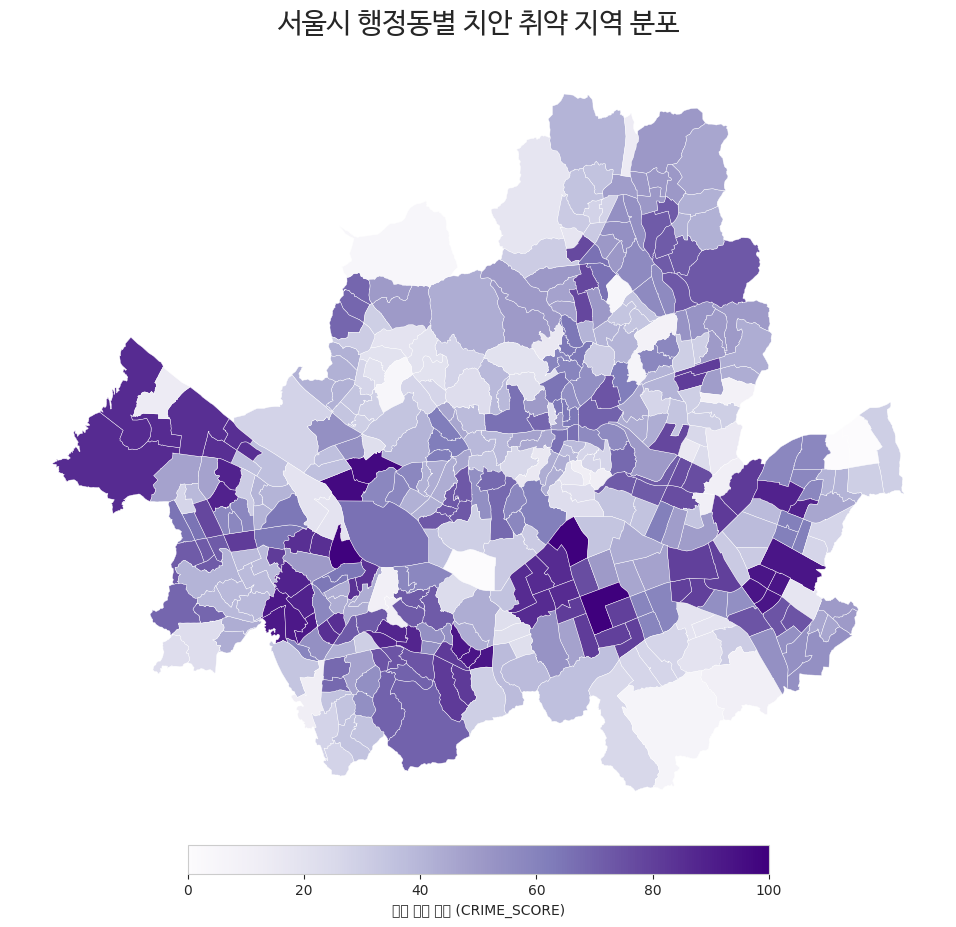

In [58]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)

fig, ax = plt.subplots(1, 1, figsize=(15, 12))

# 치안 지수 지도 시각화
crime_gdf.plot(
    column='CRIME_SCORE',
    cmap='Purples', # 치안의 엄중함을 나타내는 보라색 계열
    legend=True,
    legend_kwds={'label': "치안 위험 지수 (CRIME_SCORE)", 'orientation': "horizontal", 'pad': 0.02, 'shrink': 0.5},
    ax=ax,
    edgecolor='white',
    linewidth=0.3
)

ax.set_title('서울시 행정동별 치안 취약 지역 분포', fontproperties=fm.FontProperties(fname=font_path, size=20), pad=20)
ax.set_axis_off()
plt.show()

/tmp/ipykernel_20055/1520119561.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=crime_gdf, x='자치구', y='CRIME_SCORE', order=order, palette='light:purple')
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/pytho

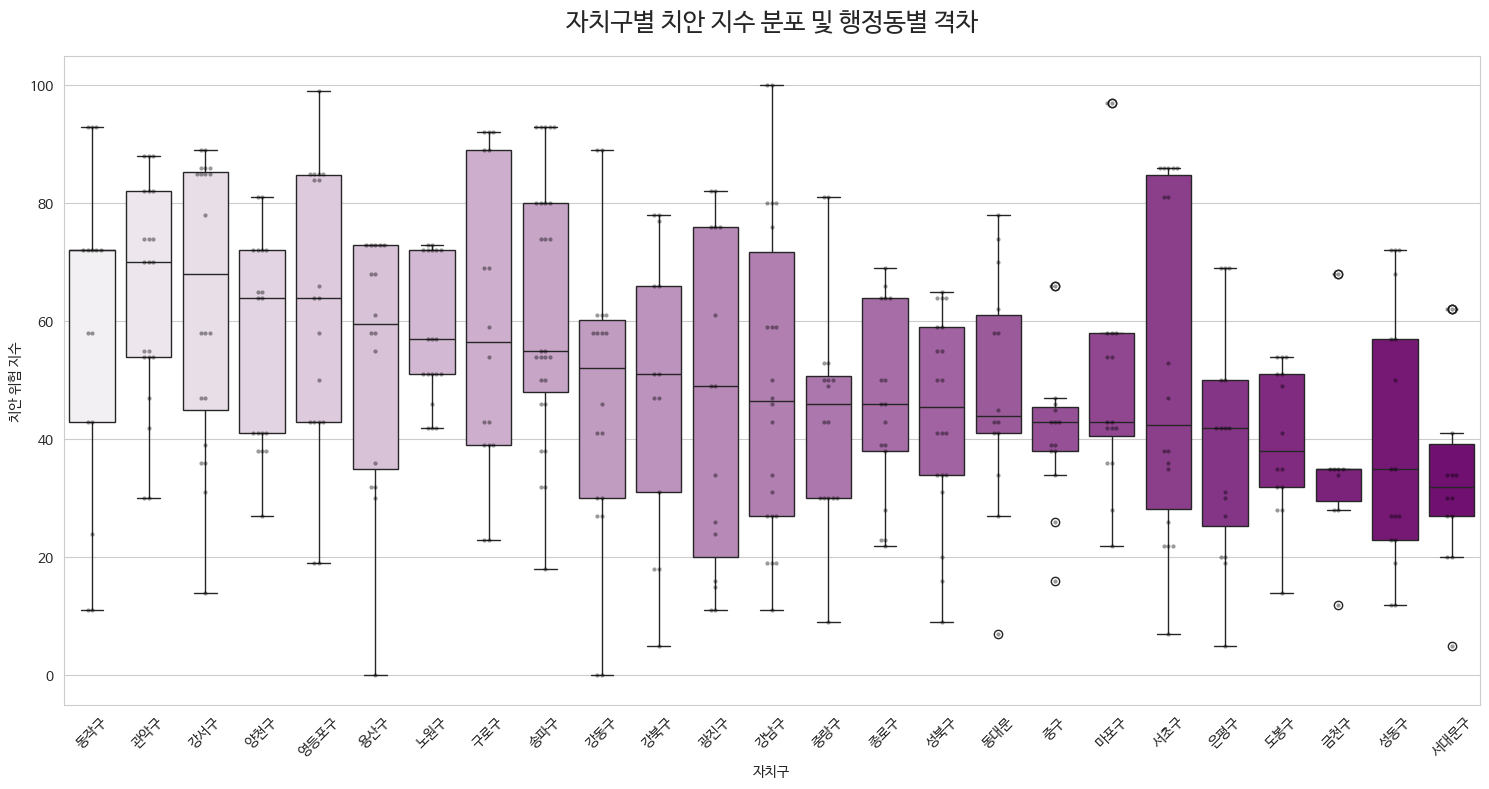

In [59]:
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

# 자치구별 중앙값 기준으로 정렬
order = crime_gdf.groupby('자치구')['CRIME_SCORE'].median().sort_values(ascending=False).index

# 박스플롯과 개별 행정동 포인트를 겹쳐서 시각화
sns.boxplot(data=crime_gdf, x='자치구', y='CRIME_SCORE', order=order, palette='light:purple')
sns.swarmplot(data=crime_gdf, x='자치구', y='CRIME_SCORE', order=order, color='black', size=3, alpha=0.4)

plt.title('자치구별 치안 지수 분포 및 행정동별 격차', fontproperties=fm.FontProperties(fname=font_path, size=18), pad=20)
plt.xticks(fontproperties=font_prop, rotation=45)
plt.yticks(fontproperties=font_prop)
plt.xlabel('자치구', fontproperties=font_prop)
plt.ylabel('치안 위험 지수', fontproperties=font_prop)

plt.tight_layout()
plt.show()

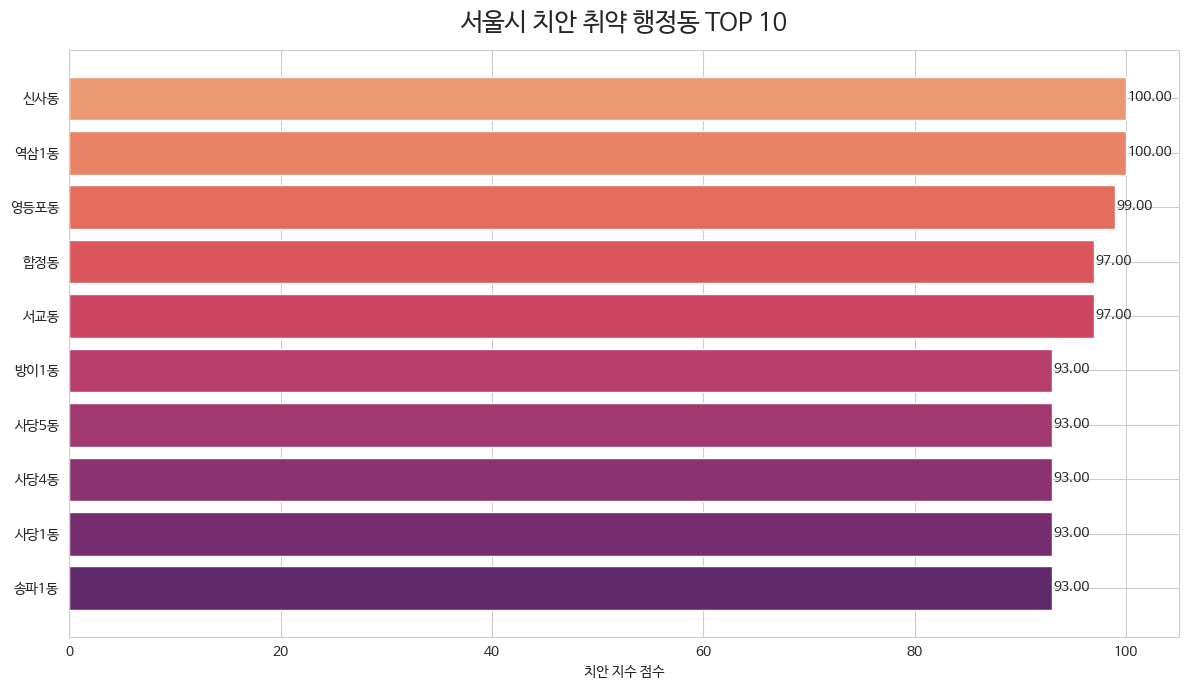

In [60]:
# 상위 10개 지역 추출
top_10_crime = crime_gdf.sort_values('CRIME_SCORE', ascending=False).head(10)

plt.figure(figsize=(12, 7))
colors = sns.color_palette("flare", len(top_10_crime))

bars = plt.barh(top_10_crime['행정동'], top_10_crime['CRIME_SCORE'], color=colors)

# 수치 표시 및 폰트 적용
plt.gca().invert_yaxis() # 높은 순서대로 위에서부터 표시
plt.title('서울시 치안 취약 행정동 TOP 10', fontproperties=fm.FontProperties(fname=font_path, size=18), pad=15)
plt.xlabel('치안 지수 점수', fontproperties=font_prop)
plt.xticks(fontproperties=font_prop)
plt.yticks(fontproperties=font_prop)

# 막대 끝에 점수 표시
for bar in bars:
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.2f}', va='center', fontproperties=font_prop)

plt.tight_layout()
plt.show()